### Time Domain Signals

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

# Let's generate some signals we explored in the last lecture 

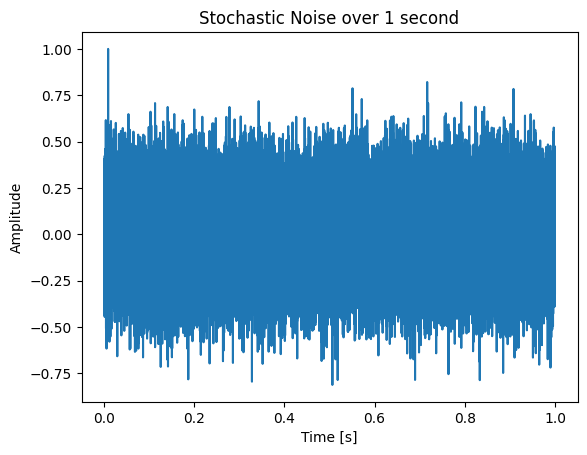

In [2]:
#White Noise with numpy

whiteNoise = np.random.normal(loc=0.0, scale=1.0, size=44100)

#Normalize to the peak amplitude of the signal
peakAmplitude = np.max(np.abs(whiteNoise))
whiteNoise = whiteNoise/peakAmplitude

#A Time Axis
timeAxis = np.linspace(0,1,44100)

plt.plot(timeAxis, whiteNoise)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Stochastic Noise over 1 second")
plt.show()


# Loading a Wavfile With Scipy

We are using `scipy.io.wavfile.read`, you will find the documentation here:

https://docs.scipy.org/doc/scipy-1.15.0/reference/generated/scipy.io.wavfile.read.html

Feel free to download interesting audio files from freesound:
https://freesound.org


/tmp/ipykernel_18518/4185211887.py:6: WavFileWarning: Chunk (non-data) not understood, skipping it.
  samplerate, data = wavfile.read(wavPath)


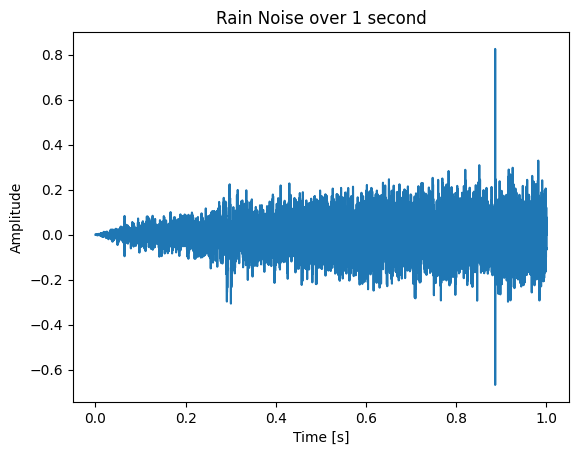

In [3]:
#Loading a signal with scipy

from scipy.io import wavfile

wavPath = "418101__buzei__vroxi.wav"
samplerate, data = wavfile.read(wavPath)

# Ensure we only take one channel, if signal is stereo
if data.ndim == 1:
    data = data
else:
    data = data[:, 0]
    
#A time axis
timeAxis = np.linspace(0,1,44100)

#Normalize to the peak amplitude of the signal
peakAmplitude = np.max(np.abs(data))
data = data/peakAmplitude

#plotting the loaded waveform

plt.plot(timeAxis, data[0:len(timeAxis)])
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Rain Noise over 1 second")
plt.show()


#### Generate A Sine Wave, Periodic Signal

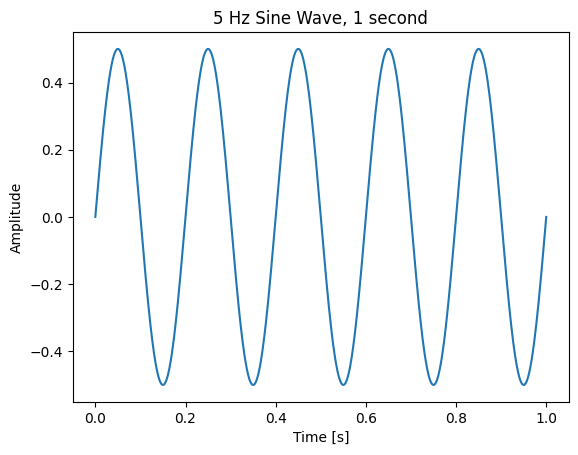

In [4]:

samplerate = 1000  # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 0.5*np.sin(2*np.pi*freq*timeAxis)

plt.plot(timeAxis, sineWave)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("5 Hz Sine Wave, 1 second")
plt.show()

### Activity - Load and Observe some Quasi-Periodic Waveforms

Explore sounds from freesound:https://freesound.org
, load the waveform and visualize it.

Plot some:
  1. Transients (Snare drum, hand clap)
  2. Textures (Rain, Fire Crackling)
  3. Speech Signals
  4. Music Signals

## Some Basic Sequences To Know

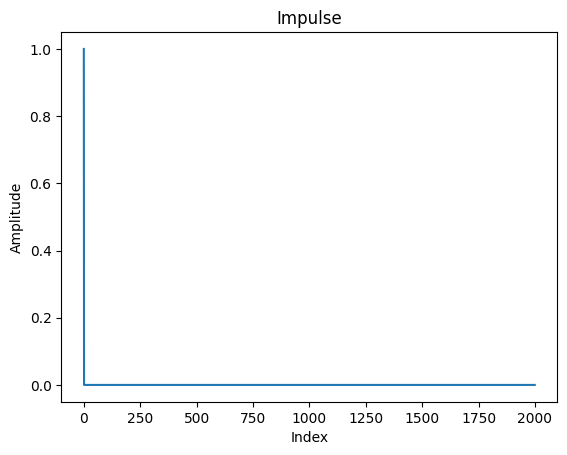

In [5]:
# Impulse

impulse = np.zeros(2000)
impulse[0] = 1

plt.plot(impulse)
plt.xlabel("Index")
plt.ylabel("Amplitude")
plt.title("Impulse")
plt.show()

# note: Self practice: Try shifting the impulse and experimenting with 
# the properties of an impulse signal


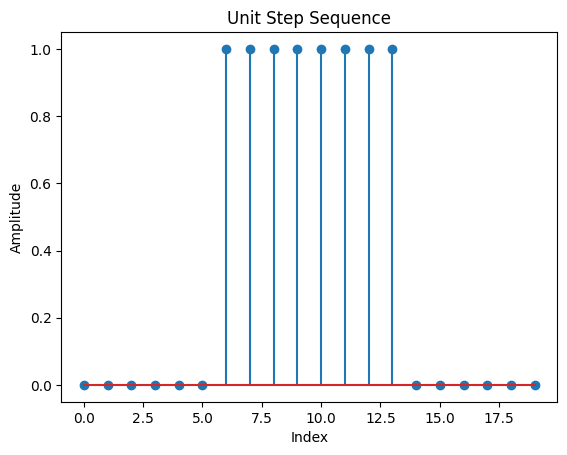

In [6]:
# Unit Step

step = np.zeros(20)
step[6:14] = 1

plt.stem(step)
plt.xlabel("Index")
plt.ylabel("Amplitude")
plt.title("Unit Step Sequence")
plt.show()


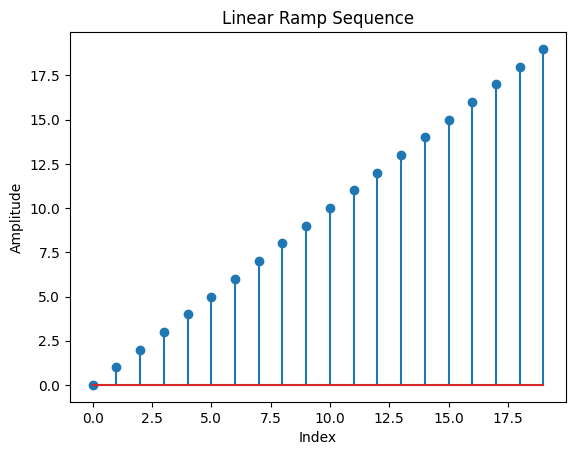

In [7]:
# Linear Ramp

linearRamp = np.arange(0,20)


plt.stem(linearRamp)
plt.xlabel("Index")
plt.ylabel("Amplitude")
plt.title("Linear Ramp Sequence")
plt.show()

#note: Self practice -> How would you make this exponential??
# Can this work with linspace?

### Common operations on signals

![title](Schem.svg)

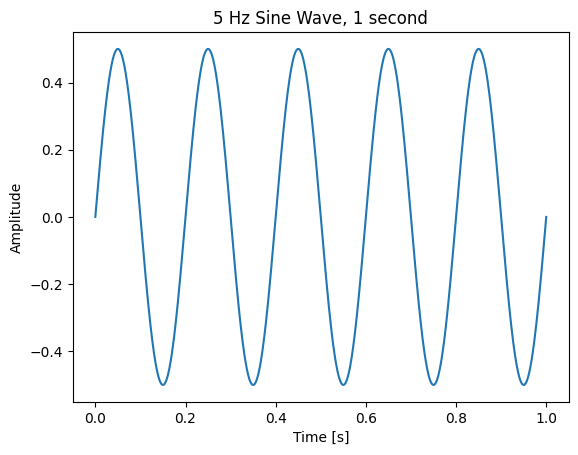

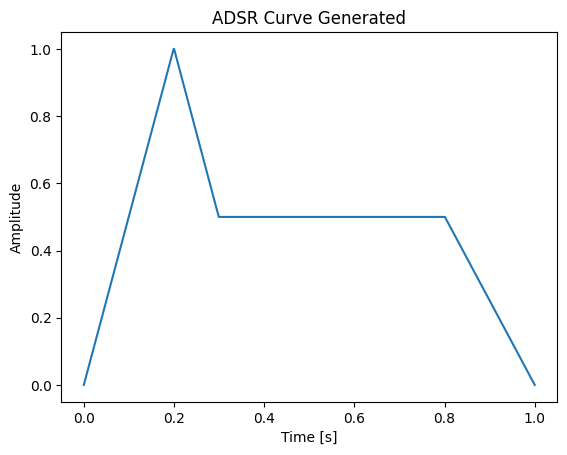

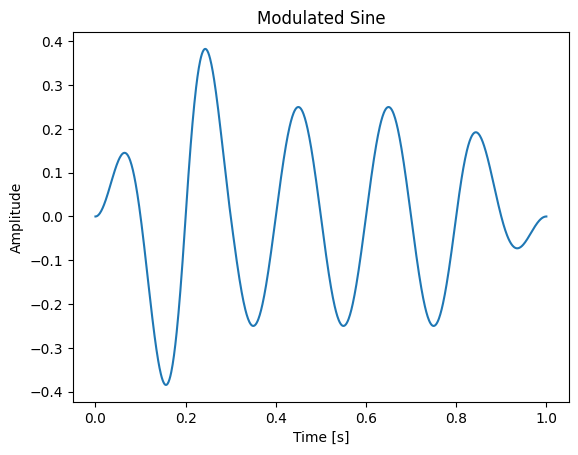

In [8]:
# Implement ADSR On The Previously Generated Sine


samplerate = 1000 # 1000 points every second
# 1 second of audio
timeAxis  = np.linspace(0, 1, samplerate)
freq = 5
sineWave = 0.5*np.sin(2*np.pi*freq*timeAxis)

plt.plot(timeAxis, sineWave)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("5 Hz Sine Wave, 1 second")
plt.show()

#Assume sustain level is 50%

def ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate):
    
    # An attack is a linear ramp up
    attack = np.linspace(0,1,int(samplerate*attackTime))
    # An Decay is a linear ramp down
    decay = np.linspace(1,0.5,int(samplerate*decayTime))
    #Sustain is a unit-step function
    sustain = np.linspace(0.5,0.5,int(samplerate*sustainTime))
    # Release is another linear ramp down
    release = np.linspace(0.5,0,int(samplerate*releaseTime))
    
    adsr = np.concatenate((attack,decay, sustain, release), axis=None)
    return adsr

# Parameters in seconds
attackTime = 0.2
decayTime = 0.1
sustainTime = 0.5
releaseTime = 0.2

#Calling the function
adsr = ADSR(attackTime, decayTime, sustainTime, releaseTime, samplerate)

plt.figure()
plt.plot(timeAxis,adsr)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("ADSR Curve Generated")
plt.show()


w = sineWave*adsr


plt.figure()
plt.plot(timeAxis,w)
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.title("Modulated Sine")
plt.show()
